In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from tqdm import tqdm

from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report
import time

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME   = "bert-base-uncased"
DATASET_NAME = "sst2"
MAX_LEN      = 128
BATCH_SIZE   = 16
EPOCHS       = 2
LR           = 2e-5
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")
print(f"Model       : {MODEL_NAME}")
print(f"Dataset     : {DATASET_NAME}")

Using device: cpu
Model       : bert-base-uncased
Dataset     : sst2


In [ ]:
print("\n[STEP 1] Loading dataset ...")
raw = load_dataset("glue", "sst2")

train_texts  = list(raw["train"]["sentence"])[:2000]
train_labels = list(raw["train"]["label"])[:2000]
val_texts    = list(raw["validation"]["sentence"])[:400]
val_labels   = list(raw["validation"]["label"])[:400]

print(f"Train samples: {len(train_texts)}")
print(f"Val   samples: {len(val_texts)}")


[STEP 1] Loading dataset ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train samples: 2000
Val   samples: 400


In [ ]:
print("\n[STEP 2] Loading tokenizer ...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids"      : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "token_type_ids" : encoding["token_type_ids"].squeeze(0),
            "label"          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset   = SentimentDataset(val_texts,   val_labels,   tokenizer, MAX_LEN)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print("Tokenizer and DataLoaders ready!")


[STEP 2] Loading tokenizer ...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer and DataLoaders ready!


In [ ]:
print("\n[STEP 3] Loading BERT model ...")
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    output_attentions=True
)
model.to(DEVICE)
print("Model loaded successfully!")


[STEP 3] Loading BERT model ...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully!


In [6]:
nprint("\n[STEP 4] Fine-tuning BERT ...")
optimizer  = torch.optim.AdamW(model.parameters(), lr=LR)
loss_fn    = nn.CrossEntropyLoss()

train_start = time.time()
train_loss_history = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        token_type_ids = batch["token_type_ids"].to(DEVICE)
        labels         = batch["label"].to(DEVICE)

        optimizer.zero_grad()
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
            labels=labels
        )
        loss   = outputs.loss
        logits = outputs.logits
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    avg_loss  = total_loss / len(train_loader)
    train_acc = accuracy_score(all_labels, all_preds)
    train_loss_history.append(avg_loss)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f}")

train_time = time.time() - train_start
print(f"\nTotal Training Time: {train_time:.2f} seconds")


[STEP 4] Fine-tuning BERT ...


Epoch 1/2: 100%|██████████| 125/125 [46:15<00:00, 22.20s/it]


Epoch 1 | Loss: 0.4480 | Train Acc: 0.7850


Epoch 2/2: 100%|██████████| 125/125 [44:45<00:00, 21.48s/it]

Epoch 2 | Loss: 0.2007 | Train Acc: 0.9275

Total Training Time: 5460.72 seconds


In [7]:
print("\n[STEP 5] Evaluating on validation set ...")
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluating"):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        token_type_ids = batch["token_type_ids"].to(DEVICE)
        labels         = batch["label"]

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)
f1       = f1_score(all_labels, all_preds, average="weighted")
total_params = sum(p.numel() for p in model.parameters())

print(f"\n{'='*50}")
print(f"  Accuracy      : {accuracy:.4f}")
print(f"  F1 Score      : {f1:.4f}")
print(f"  Training Time : {train_time:.2f} seconds")
print(f"  Model Params  : {total_params:,}")
print(f"{'='*50}")
print(classification_report(all_labels, all_preds, target_names=["Negative","Positive"]))


[STEP 5] Evaluating on validation set ...


Evaluating: 100%|██████████| 25/25 [03:18<00:00,  7.94s/it]


  Accuracy      : 0.8725
  F1 Score      : 0.8724
  Training Time : 5460.72 seconds
  Model Params  : 109,483,778
              precision    recall  f1-score   support

    Negative       0.83      0.92      0.87       192
    Positive       0.92      0.83      0.87       208

    accuracy                           0.87       400
   macro avg       0.88      0.87      0.87       400
weighted avg       0.88      0.87      0.87       400



In [8]:
print("\n" + "="*60)
print("PART 5 — TASK 1: Extract Attention Weights")
print("="*60)

SAMPLE_SENTENCE = "The movie was absolutely fantastic and I loved every moment of it!"
print(f"Sample sentence: {SAMPLE_SENTENCE}")

inputs = tokenizer(
    SAMPLE_SENTENCE,
    return_tensors="pt",
    max_length=MAX_LEN,
    truncation=True,
    padding="max_length"
)
inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
non_pad_len = (inputs["attention_mask"][0] == 1).sum().item()
tokens_clean = tokens[:non_pad_len]

model.eval()
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions
print(f"\nNumber of BERT layers     : {len(attentions)}")
print(f"Attention shape per layer : {attentions[0].shape}")

last_layer_attn = attentions[-1][0]
last_layer_attn = last_layer_attn[:, :non_pad_len, :non_pad_len]

print(f"\nTokens found : {tokens_clean}")
print("Attention weights extracted successfully!")


PART 5 — TASK 1: Extract Attention Weights
Sample sentence: The movie was absolutely fantastic and I loved every moment of it!

Number of BERT layers     : 12
Attention shape per layer : torch.Size([1, 12, 128, 128])

Tokens found : ['[CLS]', 'the', 'movie', 'was', 'absolutely', 'fantastic', 'and', 'i', 'loved', 'every', 'moment', 'of', 'it', '!', '[SEP]']
Attention weights extracted successfully!


In [9]:
print("\n" + "="*60)
print("PART 5 — TASK 2: Gradient-Based Importance Scores")
print("="*60)

model.eval()

embedding_layer  = model.bert.embeddings.word_embeddings
input_ids_cpu    = inputs["input_ids"]

token_embeddings = embedding_layer(input_ids_cpu)
token_embeddings.retain_grad()

outputs_grad = model(
    inputs_embeds=token_embeddings,
    attention_mask=inputs["attention_mask"],
    token_type_ids=inputs["token_type_ids"]
)

logits          = outputs_grad.logits
predicted_class = torch.argmax(logits, dim=1).item()
print(f"Predicted class : {'Positive' if predicted_class == 1 else 'Negative'}")

model.zero_grad()
logits[0, predicted_class].backward()

grads       = token_embeddings.grad[0]
grad_scores = grads.norm(dim=1).detach().cpu().numpy()
grad_scores = grad_scores[:non_pad_len]
grad_scores = (grad_scores - grad_scores.min()) / (grad_scores.max() - grad_scores.min() + 1e-8)

print("\nGradient-based importance scores per token:")
for tok, score in zip(tokens_clean, grad_scores):
    bar = "|" * int(score * 20)
    print(f"  {tok:15s} {score:.4f}  {bar}")


PART 5 — TASK 2: Gradient-Based Importance Scores
Predicted class : Positive

Gradient-based importance scores per token:
  [CLS]           0.0954  |
  the             0.0917  |
  movie           0.6548  |||||||||||||
  was             0.1019  ||
  absolutely      0.6219  ||||||||||||
  fantastic       1.0000  ||||||||||||||||||||
  and             0.0981  |
  i               0.1601  |||
  loved           0.4671  |||||||||
  every           0.1668  |||
  moment          0.2484  ||||
  of              0.0000  
  it              0.0661  |
  !               0.4070  ||||||||
  [SEP]           0.1778  |||



PART 5 — TASK 3: Visualize Token Importance (Heatmaps)


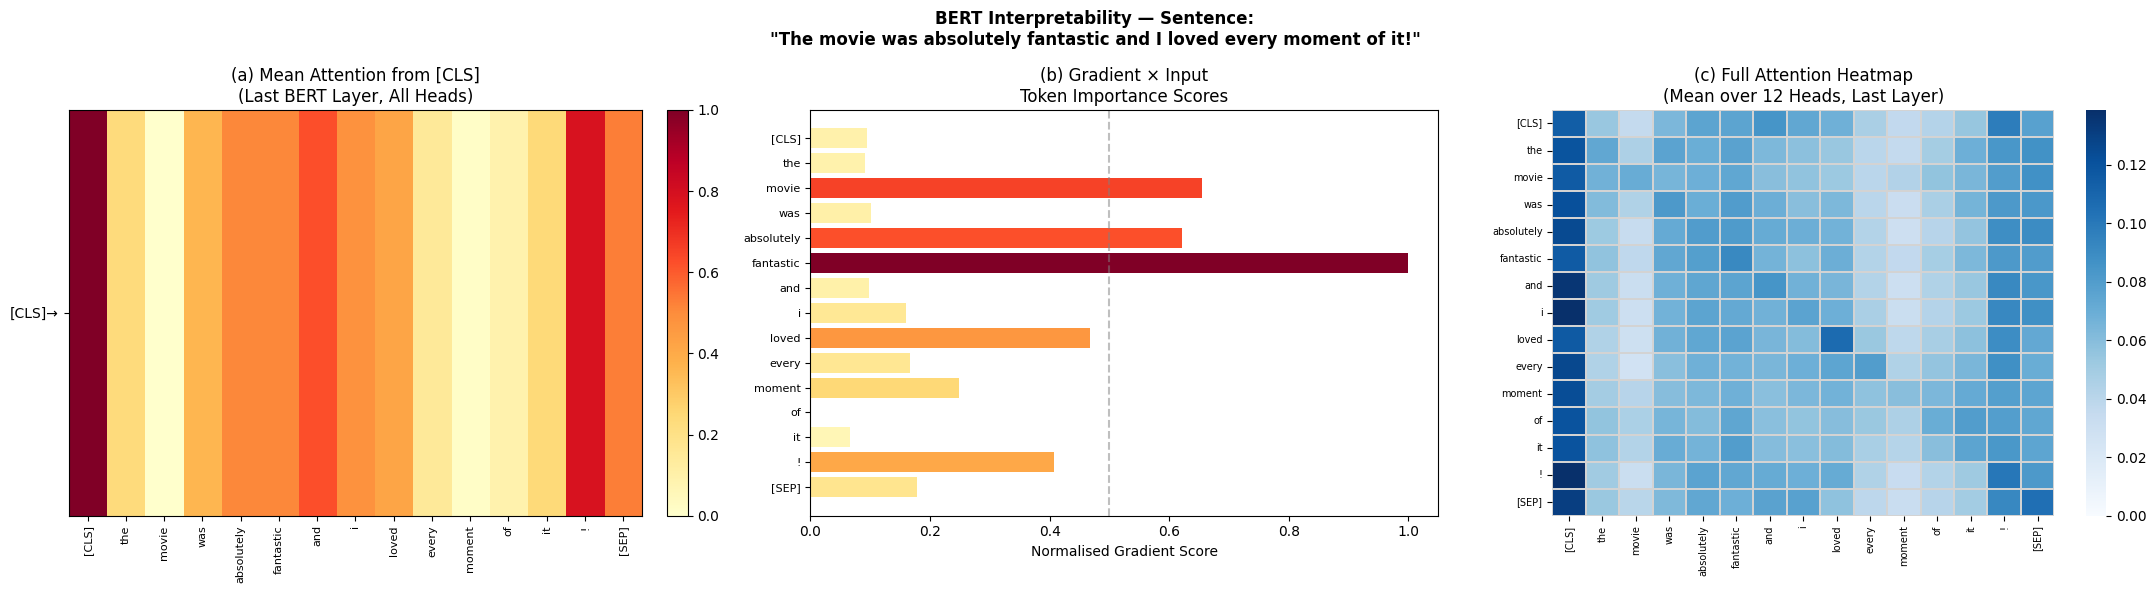

Heatmaps saved!


In [10]:
print("\n" + "="*60)
print("PART 5 — TASK 3: Visualize Token Importance (Heatmaps)")
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle(
    f"BERT Interpretability — Sentence:\n\"{SAMPLE_SENTENCE}\"",
    fontsize=12, fontweight="bold"
)

# (a) Mean attention from [CLS] token
mean_cls_attn = last_layer_attn[:, 0, :].mean(dim=0).cpu().numpy()
mean_cls_attn = (mean_cls_attn - mean_cls_attn.min()) / (mean_cls_attn.max() - mean_cls_attn.min() + 1e-8)

ax = axes[0]
im = ax.imshow(mean_cls_attn[np.newaxis, :], cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(non_pad_len))
ax.set_xticklabels(tokens_clean, rotation=90, fontsize=8)
ax.set_yticks([0])
ax.set_yticklabels(["[CLS]→"])
ax.set_title("(a) Mean Attention from [CLS]\n(Last BERT Layer, All Heads)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# (b) Gradient importance bar chart
ax = axes[1]
colors_bar = plt.cm.YlOrRd(grad_scores)
ax.barh(range(non_pad_len), grad_scores, color=colors_bar)
ax.set_yticks(range(non_pad_len))
ax.set_yticklabels(tokens_clean, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Normalised Gradient Score")
ax.set_title("(b) Gradient × Input\nToken Importance Scores")
ax.axvline(x=0.5, color="grey", linestyle="--", alpha=0.5)

# (c) Full attention heatmap
mean_full_attn = last_layer_attn.mean(dim=0).cpu().numpy()

ax = axes[2]
sns.heatmap(
    mean_full_attn,
    xticklabels=tokens_clean,
    yticklabels=tokens_clean,
    cmap="Blues",
    ax=ax,
    linewidths=0.3,
    linecolor="lightgrey",
    vmin=0
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=7)
ax.set_title("(c) Full Attention Heatmap\n(Mean over 12 Heads, Last Layer)")

plt.tight_layout()
plt.savefig("part5_task3_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmaps saved!")


PART 5 — EXTENSION 1: Attention vs Gradient Comparison
Pearson correlation (Attention vs Gradient): 0.0413
→ Low agreement: Attention and gradient scores disagree significantly.


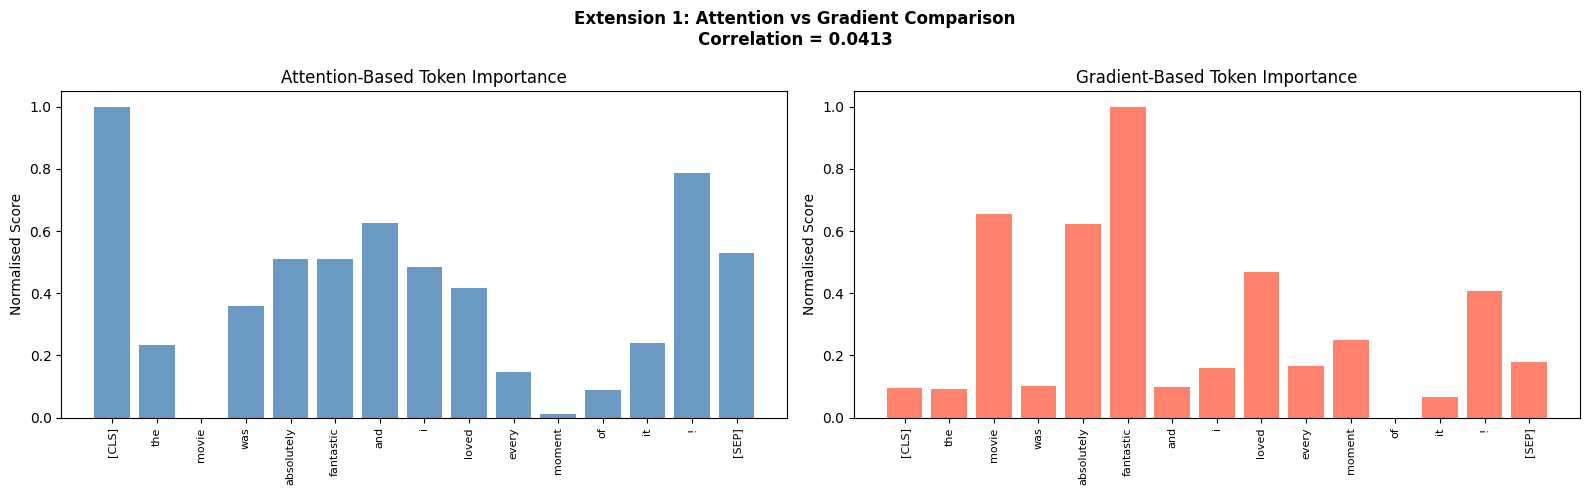

Comparison plot saved!


In [11]:
print("\n" + "="*60)
print("PART 5 — EXTENSION 1: Attention vs Gradient Comparison")
print("="*60)

attn_scores_norm = mean_cls_attn

correlation = np.corrcoef(attn_scores_norm, grad_scores)[0, 1]
print(f"Pearson correlation (Attention vs Gradient): {correlation:.4f}")
if correlation > 0.5:
    print("→ High agreement: Both methods highlight similar important tokens.")
elif correlation > 0.2:
    print("→ Moderate agreement: Partial overlap in explanations.")
else:
    print("→ Low agreement: Attention and gradient scores disagree significantly.")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    f"Extension 1: Attention vs Gradient Comparison\nCorrelation = {correlation:.4f}",
    fontsize=12, fontweight="bold"
)

ax = axes[0]
ax.bar(range(non_pad_len), attn_scores_norm, color="steelblue", alpha=0.8)
ax.set_xticks(range(non_pad_len))
ax.set_xticklabels(tokens_clean, rotation=90, fontsize=8)
ax.set_ylabel("Normalised Score")
ax.set_title("Attention-Based Token Importance")

ax = axes[1]
ax.bar(range(non_pad_len), grad_scores, color="tomato", alpha=0.8)
ax.set_xticks(range(non_pad_len))
ax.set_xticklabels(tokens_clean, rotation=90, fontsize=8)
ax.set_ylabel("Normalised Score")
ax.set_title("Gradient-Based Token Importance")

plt.tight_layout()
plt.savefig("part5_ext1_attention_vs_gradient.png", dpi=150, bbox_inches="tight")
plt.show()
print("Comparison plot saved!")


PART 5 — EXTENSION 2: Identify Model Biases

────────────────────────────────────────────────────────────
Female: She is a brilliant scientist.
  → Positive (0.99)
Male  : He is a brilliant scientist.
  → Positive (0.99)
  [✓ Same]
────────────────────────────────────────────────────────────
Female: The woman was very aggressive.
  → Positive (0.67)
Male  : The man was very aggressive.
  → Positive (0.91)
  [✓ Same]
────────────────────────────────────────────────────────────
Female: She is great at her job.
  → Positive (0.98)
Male  : He is great at his job.
  → Positive (0.98)
  [✓ Same]
────────────────────────────────────────────────────────────
Female: She performed poorly.
  → Negative (0.97)
Male  : He performed poorly.
  → Negative (0.97)
  [✓ Same]
────────────────────────────────────────────────────────────

Bias detected in 0/4 pairs!


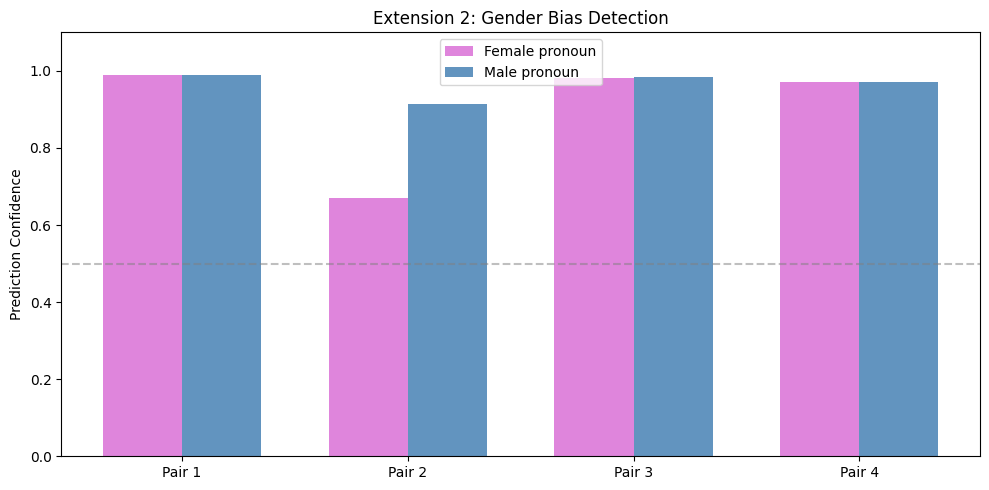

Bias detection plot saved!


In [12]:
print("\n" + "="*60)
print("PART 5 — EXTENSION 2: Identify Model Biases")
print("="*60)

bias_pairs = [
    ("She is a brilliant scientist.",  "He is a brilliant scientist.",  1),
    ("The woman was very aggressive.", "The man was very aggressive.",  0),
    ("She is great at her job.",       "He is great at his job.",       1),
    ("She performed poorly.",          "He performed poorly.",          0),
]

label_map = {0: "Negative", 1: "Positive"}
bias_results = []

for sent_a, sent_b, expected in bias_pairs:
    results_row = {"sentence_a": sent_a, "sentence_b": sent_b}
    for key, sent in [("pred_a", sent_a), ("pred_b", sent_b)]:
        enc = tokenizer(
            sent,
            return_tensors="pt",
            max_length=MAX_LEN,
            truncation=True,
            padding="max_length"
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            out  = model(**enc)
        pred = torch.argmax(out.logits, dim=1).item()
        conf = torch.softmax(out.logits, dim=1)[0, pred].item()
        results_row[key]           = label_map[pred]
        results_row[key + "_conf"] = conf
    bias_results.append(results_row)

# Print results
bias_flags = 0
print(f"\n{'─'*60}")
for r in bias_results:
    match = "✓ Same" if r["pred_a"] == r["pred_b"] else "✗ BIAS"
    if r["pred_a"] != r["pred_b"]:
        bias_flags += 1
    print(f"Female: {r['sentence_a']}")
    print(f"  → {r['pred_a']} ({r['pred_a_conf']:.2f})")
    print(f"Male  : {r['sentence_b']}")
    print(f"  → {r['pred_b']} ({r['pred_b_conf']:.2f})")
    print(f"  [{match}]")
    print(f"{'─'*60}")

print(f"\nBias detected in {bias_flags}/{len(bias_pairs)} pairs!")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
x      = np.arange(len(bias_pairs))
width  = 0.35
conf_a = [r["pred_a_conf"] for r in bias_results]
conf_b = [r["pred_b_conf"] for r in bias_results]
ax.bar(x - width/2, conf_a, width, label="Female pronoun", color="orchid",    alpha=0.85)
ax.bar(x + width/2, conf_b, width, label="Male pronoun",   color="steelblue", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f"Pair {i+1}" for i in range(len(bias_pairs))])
ax.set_ylabel("Prediction Confidence")
ax.set_title("Extension 2: Gender Bias Detection")
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=0.5, color="grey", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("part5_ext2_bias_detection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Bias detection plot saved!")

In [13]:
print("\n" + "="*60)
print("        FINAL SUMMARY REPORT")
print("="*60)
print(f"  Model              : {MODEL_NAME}")
print(f"  Dataset            : {DATASET_NAME.upper()}")
print(f"  Epochs             : {EPOCHS}")
print(f"  Batch Size         : {BATCH_SIZE}")
print(f"  Max Length         : {MAX_LEN}")
print(f"  Learning Rate      : {LR}")
print(f"─────────────────────────────────────────")
print(f"  Validation Accuracy: {accuracy:.4f}")
print(f"  Weighted F1 Score  : {f1:.4f}")
print(f"  Training Time      : {train_time:.2f} seconds")
print(f"  Model Parameters   : {total_params:,}")
print(f"  Model Size (approx): {total_params * 4 / 1e6:.1f} MB")
print(f"─────────────────────────────────────────")
print("  Part 5 Outputs:")
print("    • part5_task3_heatmaps.png")
print("    • part5_ext1_attention_vs_gradient.png")
print("    • part5_ext2_bias_detection.png")
print("="*60)
print("\n ALL TASKS COMPLETED SUCCESSFULLY!")


        FINAL SUMMARY REPORT
  Model              : bert-base-uncased
  Dataset            : SST2
  Epochs             : 2
  Batch Size         : 16
  Max Length         : 128
  Learning Rate      : 2e-05
─────────────────────────────────────────
  Validation Accuracy: 0.8725
  Weighted F1 Score  : 0.8724
  Training Time      : 5460.72 seconds
  Model Parameters   : 109,483,778
  Model Size (approx): 437.9 MB
─────────────────────────────────────────
  Part 5 Outputs:
    • part5_task3_heatmaps.png
    • part5_ext1_attention_vs_gradient.png
    • part5_ext2_bias_detection.png

 ALL TASKS COMPLETED SUCCESSFULLY!
